In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

folder_path = '/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/UNSW-NB15-test/'

try:
    X_train = pd.read_csv(folder_path + 'X_train.csv')
    X_test = pd.read_csv(folder_path + 'X_test.csv')
    y_train = pd.read_csv(folder_path + 'y_train.csv')
    y_test = pd.read_csv(folder_path + 'y_test.csv')

    y_train = y_train.values.ravel()
    y_test = y_test.values.ravel()
except Exception as e:
    print(f"Problem z ładowaniem plików: {e}")

def zapisz_macierz_pomylek(cm, tytul="Macierz pomyłek", nazwa_pliku="confusion_matrix.png"):
    katalog_docelowy = os.path.join(folder_path, "confusion_matrix")
    os.makedirs(katalog_docelowy, exist_ok=True)
    pelna_sciezka = os.path.join(katalog_docelowy, nazwa_pliku)

    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'Liberation Sans', 'DejaVu Sans']
    plt.figure(figsize=(6, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ruch bezpieczny', 'Atak'],
                yticklabels=['Ruch bezpieczny', 'Atak'], square=True, cbar=False,
                linewidths=1, linecolor='white', annot_kws={"size": 12})

    plt.title(tytul, fontsize=15, pad=15, weight='bold')
    plt.ylabel('Rzeczywista klasa', fontsize=14)
    plt.xlabel('Predykcja modelu', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()
    plt.savefig(pelna_sciezka, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
    plt.show()
    plt.close()

def zapisz_raport_klasyfikacji(y_true, y_pred, nazwa_pliku="raport_klasyfikacji.xlsx"):
    katalog_docelowy = os.path.join(folder_path, "raporty")
    os.makedirs(katalog_docelowy, exist_ok=True)
    pelna_sciezka = os.path.join(katalog_docelowy, nazwa_pliku)

    raport_slownik = classification_report(y_true, y_pred, output_dict=True)
    df_raport = pd.DataFrame(raport_slownik).transpose().round(2)

    if 'support' in df_raport.columns:
        df_raport['support'] = df_raport['support'].astype(int)

    df_raport.to_excel(pelna_sciezka, index=True)

def zapisz_krzywa_roc(y_true, y_scores, tytul="Krzywa ROC", nazwa_pliku="roc_curve.png"):
    katalog_docelowy = os.path.join(folder_path, "roc_curves")
    os.makedirs(katalog_docelowy, exist_ok=True)
    pelna_sciezka = os.path.join(katalog_docelowy, nazwa_pliku)

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc_wartosc = roc_auc_score(y_true, y_scores)

    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'Liberation Sans', 'DejaVu Sans']
    plt.figure(figsize=(6, 5))

    plt.plot(fpr, tpr, color='#1558d6', linewidth=2, label=f'Krzywa modelu (AUC = {auc_wartosc:.4f})')
    plt.plot([0, 1], [0, 1], color='#eaa937', linestyle='--', linewidth=2, label='Klasyfikator losowy (AUC = 0.50)')

    plt.title(tytul, fontsize=16, pad=20, weight='bold')
    plt.xlabel('Odsetek fałszywych alarmów (FPR)', fontsize=13)
    plt.ylabel('Czułość (Recall / TPR)', fontsize=13)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig(pelna_sciezka, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

    return auc_wartosc

Accuracy: 0.8709
FPR: 0.2698
              precision    recall  f1-score   support

           0      0.977     0.730     0.836     37000
           1      0.817     0.986     0.894     45332

    accuracy                          0.871     82332
   macro avg      0.897     0.858     0.865     82332
weighted avg      0.889     0.871     0.868     82332



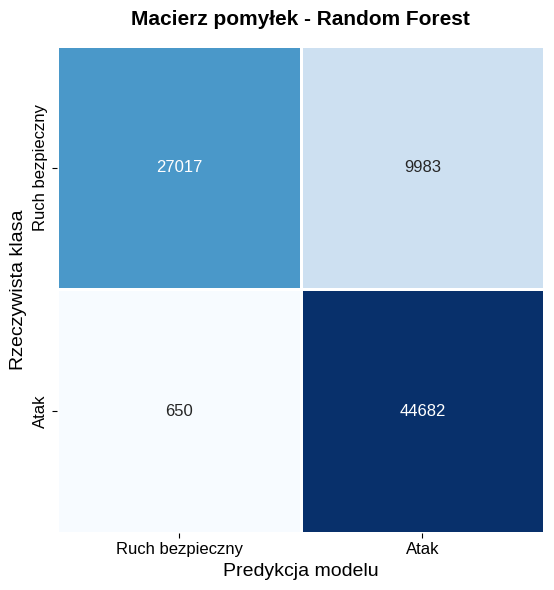

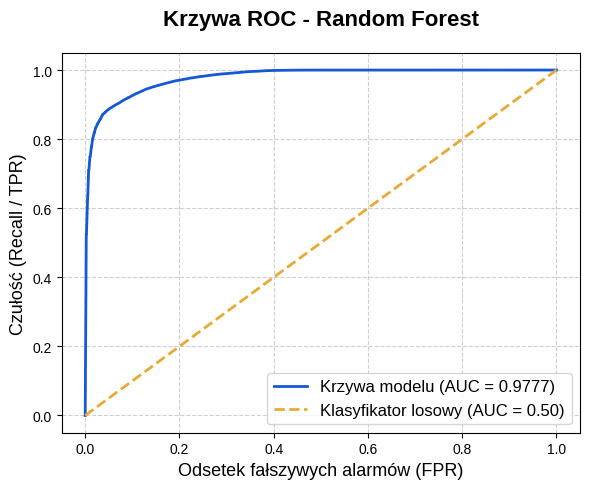

np.float64(0.9776578721909944)

In [4]:
# ============================================================
# 1. Implementacja i trenowanie modelu Random Forest
# (Domyślne parametry)
# ============================================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_scores_rf = rf_model.predict_proba(X_test)[:, 1]

cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
fpr_rf = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"FPR: {fpr_rf:.4f}")
print(classification_report(y_test, y_pred_rf, digits=3))

zapisz_macierz_pomylek(cm_rf, 'Macierz pomyłek - Random Forest', 'confusion_matrix_random_forest.png')
zapisz_raport_klasyfikacji(y_test, y_pred_rf, 'raport_random_forest.xlsx')
zapisz_krzywa_roc(y_test, y_scores_rf, 'Krzywa ROC - Random Forest', 'roc_random_forest.png')

Accuracy: 0.8260
FPR: 0.3848
              precision    recall  f1-score   support

           0      0.996     0.615     0.761     37000
           1      0.761     0.998     0.863     45332

    accuracy                          0.826     82332
   macro avg      0.878     0.807     0.812     82332
weighted avg      0.866     0.826     0.817     82332



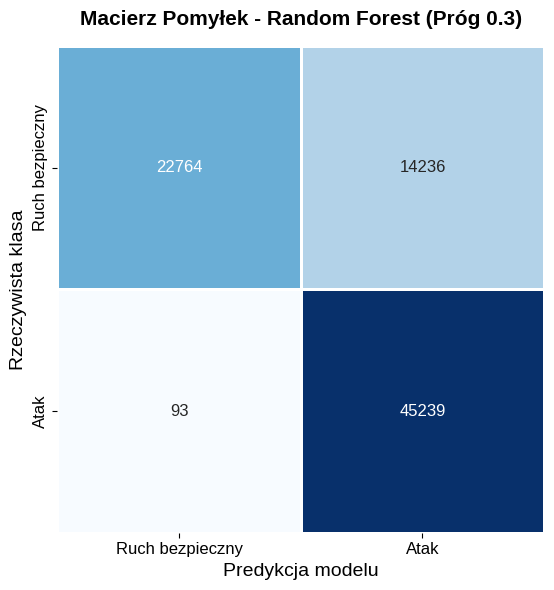

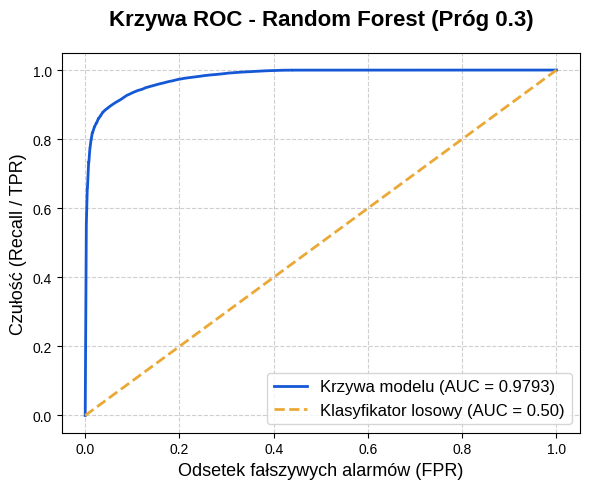

np.float64(0.9793278940835302)

In [5]:
# ============================================================
# 1.1. Implementacja i trenowanie modelu Random Forest
# (Class Weights, próg 0.3)
# ============================================================
rf_optimized = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_optimized.fit(X_train, y_train)

y_pred_proba = rf_optimized.predict_proba(X_test)[:, 1]
custom_threshold = 0.30
y_pred_rf_opt = (y_pred_proba >= custom_threshold).astype(int)

cm_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)
tn, fp, fn, tp = cm_rf_opt.ravel()
fpr_rf_opt = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_opt):.4f}")
print(f"FPR: {fpr_rf_opt:.4f}")
print(classification_report(y_test, y_pred_rf_opt, digits=3))

zapisz_macierz_pomylek(cm_rf_opt, f'Macierz Pomyłek - Random Forest (Próg {custom_threshold})', 'confusion_matrix_rf_opt.png')
zapisz_raport_klasyfikacji(y_test, y_pred_rf_opt, 'raport_random_forest_opt.xlsx')
zapisz_krzywa_roc(y_test, y_pred_proba, f'Krzywa ROC - Random Forest (Próg {custom_threshold})', 'roc_random_forest_opt.png')


Accuracy: 0.9068
FPR: 0.1654
              precision    recall  f1-score   support

           0      0.952     0.835     0.889     37000
           1      0.877     0.966     0.919     45332

    accuracy                          0.907     82332
   macro avg      0.915     0.900     0.904     82332
weighted avg      0.911     0.907     0.906     82332



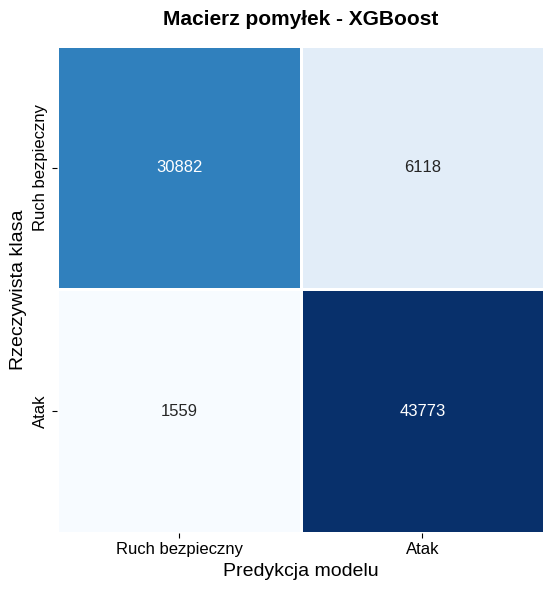

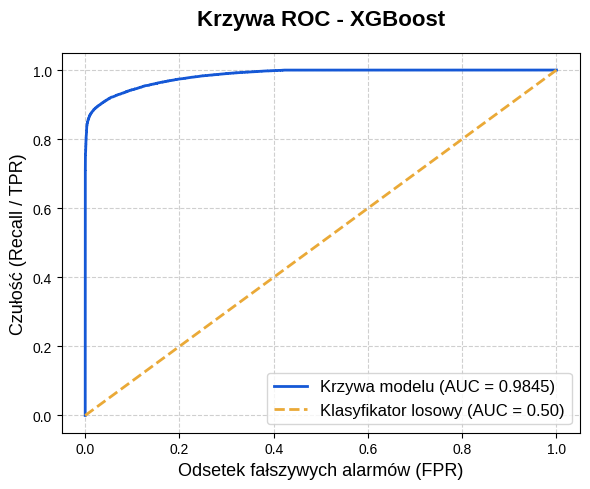

np.float64(0.9844762023008626)

In [6]:
# ============================================================
# 2. Implementacja i trenowanie modelu XGBoost
# (Domyślne parametry)
# ============================================================
stosunek_klas = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=stosunek_klas, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_scores_xgb = xgb_model.predict_proba(X_test)[:, 1]

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
fpr_xgb = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"FPR: {fpr_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, digits=3))

zapisz_macierz_pomylek(cm_xgb, 'Macierz pomyłek - XGBoost', 'confusion_matrix_xgboost.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb, 'raport_xgboost.xlsx')
zapisz_krzywa_roc(y_test, y_scores_xgb, 'Krzywa ROC - XGBoost', 'roc_xgboost.png')

Accuracy: 0.9083
FPR: 0.1539
              precision    recall  f1-score   support

           0      0.944     0.846     0.892     37000
           1      0.884     0.959     0.920     45332

    accuracy                          0.908     82332
   macro avg      0.914     0.903     0.906     82332
weighted avg      0.911     0.908     0.908     82332



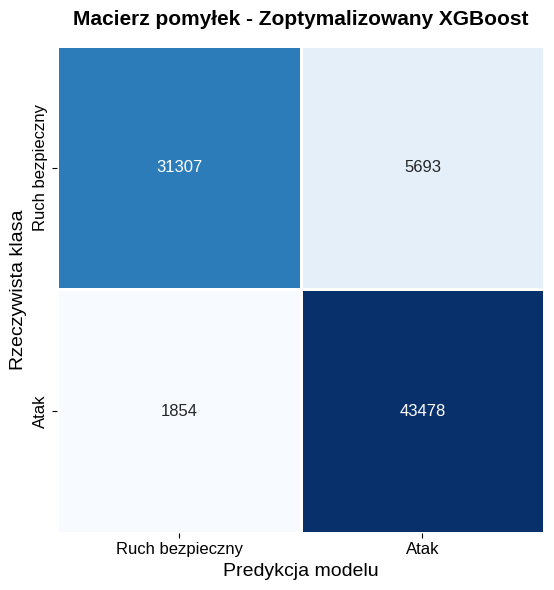

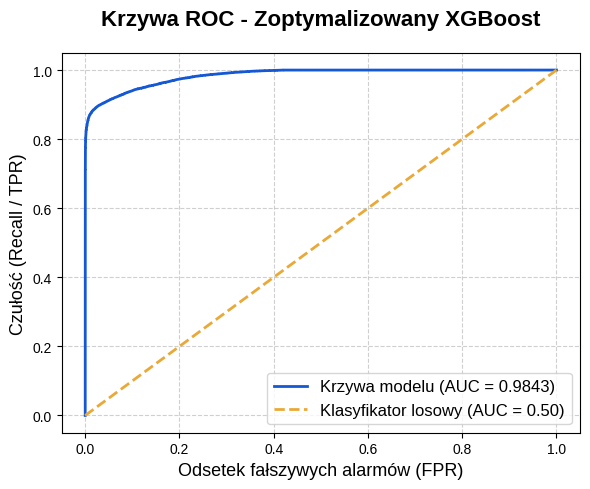

np.float64(0.9843003894987372)

In [7]:
# ============================================================
# 2.1. Implementacja i trenowanie modelu XGBoost
# (Regularization & Early Stopping)
# ============================================================
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
stosunek_klas = len(y_train_xgb[y_train_xgb == 0]) / len(y_train_xgb[y_train_xgb == 1])

xgb_model = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42, scale_pos_weight=stosunek_klas, eval_metric='logloss', early_stopping_rounds=20)
xgb_model.fit(X_train_xgb, y_train_xgb, eval_set=[(X_val_xgb, y_val_xgb)], verbose=0)

y_pred_xgb = xgb_model.predict(X_test)
y_scores_xgb_opt = xgb_model.predict_proba(X_test)[:, 1]

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
fpr_xgb = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"FPR: {fpr_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, digits=3))

zapisz_macierz_pomylek(cm_xgb, 'Macierz pomyłek - Zoptymalizowany XGBoost', 'confusion_matrix_xgboost_opt.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb, 'raport_xgboost_opt.xlsx')
zapisz_krzywa_roc(y_test, y_scores_xgb_opt, 'Krzywa ROC - Zoptymalizowany XGBoost', 'roc_xgboost_opt.png')

Accuracy: 0.9026
FPR: 0.1749
              precision    recall  f1-score   support

           0      0.952     0.825     0.884     37000
           1      0.871     0.966     0.916     45332

    accuracy                          0.903     82332
   macro avg      0.912     0.896     0.900     82332
weighted avg      0.907     0.903     0.902     82332



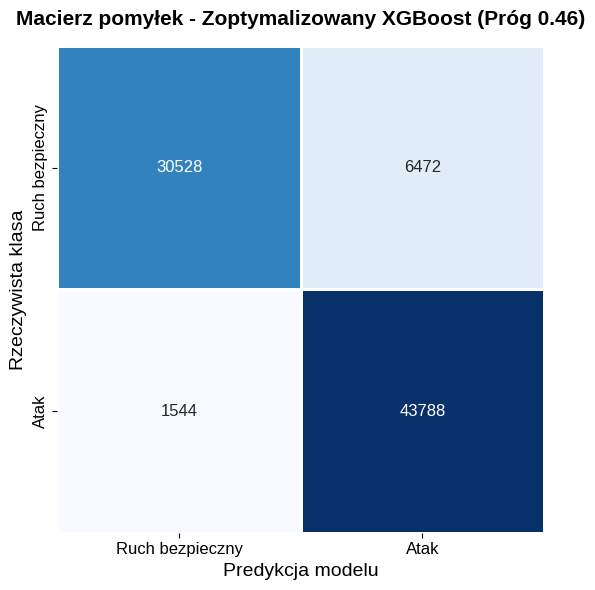

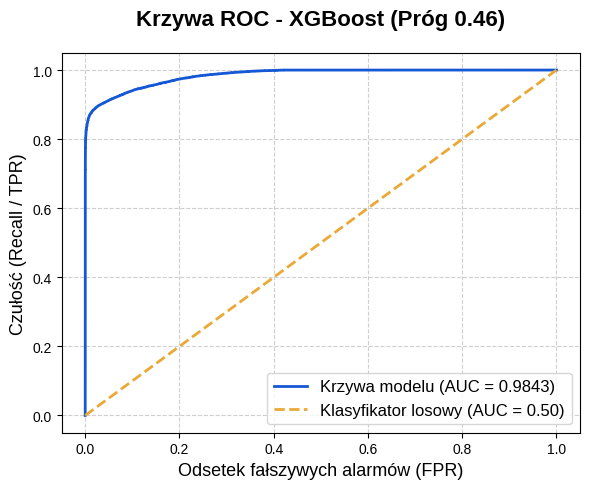

np.float64(0.9843003894987372)

In [8]:
# ============================================================
# 2.2. Implementacja i trenowanie modelu XGBoost
# (Threshold Moving)
# ============================================================
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
stosunek_klas = len(y_train_xgb[y_train_xgb == 0]) / len(y_train_xgb[y_train_xgb == 1])

xgb_model = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42, scale_pos_weight=stosunek_klas, eval_metric='logloss', early_stopping_rounds=20)
xgb_model.fit(X_train_xgb, y_train_xgb, eval_set=[(X_val_xgb, y_val_xgb)], verbose=0)

prawdopodobienstwa_val = xgb_model.predict_proba(X_val_xgb)[:, 1]
maksymalny_akceptowalny_fpr = 0.05
najlepszy_recall = 0.0
znaleziony_prog = 0.50

for prog in np.arange(0.01, 1.0, 0.01):
    y_pred_temp = (prawdopodobienstwa_val >= prog).astype(int)
    cm_temp = confusion_matrix(y_val_xgb, y_pred_temp)
    tn, fp, fn, tp = cm_temp.ravel()
    obecny_fpr = fp / (fp + tn)
    obecny_recall = recall_score(y_val_xgb, y_pred_temp)
    if obecny_fpr <= maksymalny_akceptowalny_fpr and obecny_recall > najlepszy_recall:
        najlepszy_recall = obecny_recall
        znaleziony_prog = prog

prawdopodobienstwa_test = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (prawdopodobienstwa_test >= znaleziony_prog).astype(int)

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
fpr_xgb = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"FPR: {fpr_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, digits=3))

zapisz_macierz_pomylek(cm_xgb, f'Macierz pomyłek - Zoptymalizowany XGBoost (Próg {znaleziony_prog:.2f})', 'confusion_matrix_xgboost_opt_threshold.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb, 'raport_xgboost_opt_threshold.xlsx')
zapisz_krzywa_roc(y_test, prawdopodobienstwa_test, f'Krzywa ROC - XGBoost (Próg {znaleziony_prog:.2f})', 'roc_xgboost_opt_threshold.png')

Accuracy: 0.8093
FPR: 0.4236
              precision    recall  f1-score   support

           0      0.999     0.576     0.731     37000
           1      0.743     0.999     0.852     45332

    accuracy                          0.809     82332
   macro avg      0.871     0.788     0.792     82332
weighted avg      0.858     0.809     0.798     82332



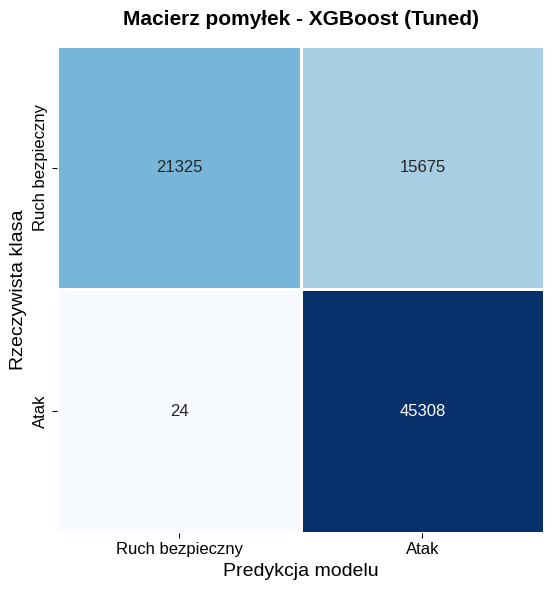

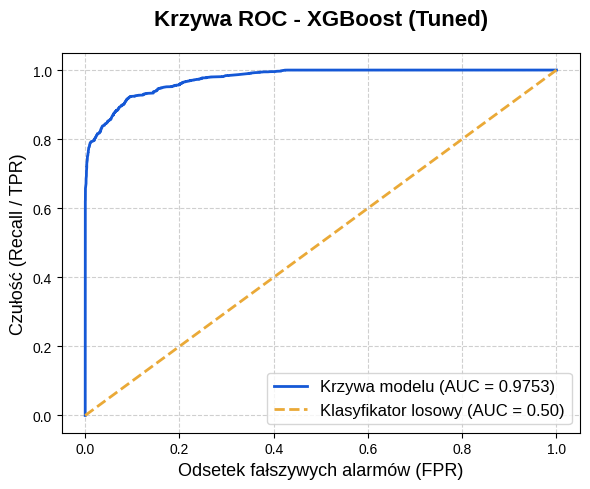

np.float64(0.975278103469657)

In [9]:
# ============================================================
# 2.3. Implementacja i trenowanie modelu XGBoost
# (Auto-Tuning)
# ============================================================
stosunek_klas = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
param_distributions = {
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'scale_pos_weight': [stosunek_klas, stosunek_klas * 1.5, stosunek_klas * 2.5],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
random_search = RandomizedSearchCV(estimator=xgb_base, param_distributions=param_distributions, n_iter=15, scoring='recall', cv=3, random_state=42, n_jobs=-1, verbose=0)
random_search.fit(X_train, y_train)

xgb_model = random_search.best_estimator_
y_pred_xgb = xgb_model.predict(X_test)
y_scores_xgb_tuned = xgb_model.predict_proba(X_test)[:, 1]

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
fpr_xgb = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"FPR: {fpr_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, digits=3))

zapisz_macierz_pomylek(cm_xgb, 'Macierz pomyłek - XGBoost (Tuned)', 'confusion_matrix_xgboost_tuned.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb, 'raport_xgboost_tuned.xlsx')
zapisz_krzywa_roc(y_test, y_scores_xgb_tuned, 'Krzywa ROC - XGBoost (Tuned)', 'roc_xgboost_tuned.png')

Accuracy: 0.8819
FPR: 0.2381
              precision    recall  f1-score   support

           0      0.968     0.762     0.853     37000
           1      0.834     0.980     0.901     45332

    accuracy                          0.882     82332
   macro avg      0.901     0.871     0.877     82332
weighted avg      0.895     0.882     0.880     82332



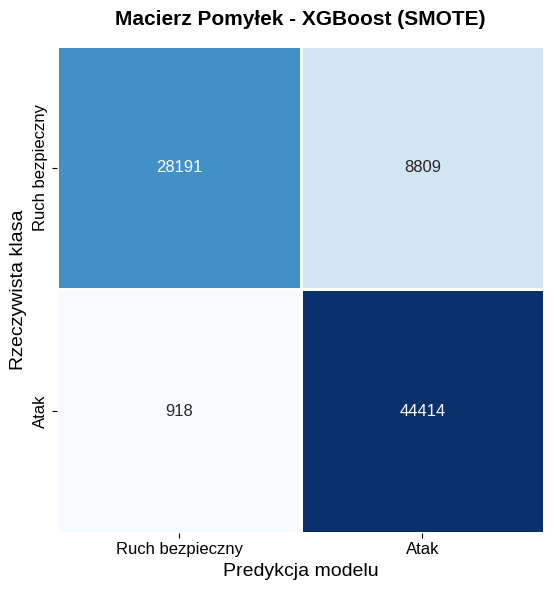

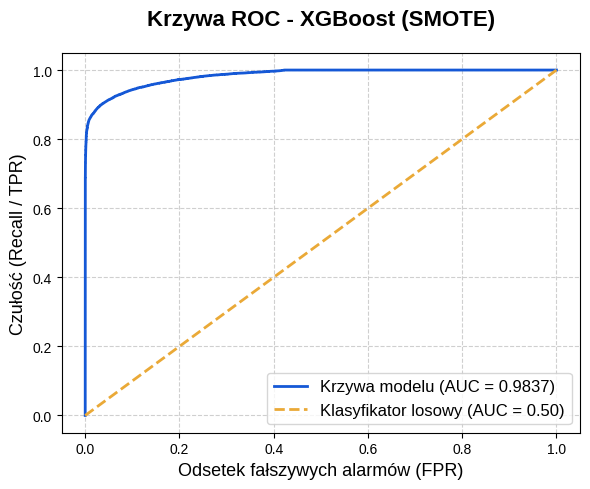

np.float64(0.9836701679620148)

In [10]:
# ============================================================
# 2.4. Implementacja i trenowanie modelu XGBoost
# (SMOTE)
# ============================================================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

xgb_smote_model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_smote_model.fit(X_train_smote, y_train_smote, eval_set=[(X_train_smote, y_train_smote), (X_test, y_test)], verbose=0)

y_pred_xgb_smote = xgb_smote_model.predict(X_test)
y_scores_xgb_smote = xgb_smote_model.predict_proba(X_test)[:, 1]

cm_xgb_smote = confusion_matrix(y_test, y_pred_xgb_smote)
tn, fp, fn, tp = cm_xgb_smote.ravel()
fpr_xgb_smote = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_smote):.4f}")
print(f"FPR: {fpr_xgb_smote:.4f}")
print(classification_report(y_test, y_pred_xgb_smote, digits=3))

zapisz_macierz_pomylek(cm_xgb_smote, 'Macierz Pomyłek - XGBoost (SMOTE)', 'confusion_matrix_xgb_smote.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb_smote, 'raport_xgb_smote.xlsx')
zapisz_krzywa_roc(y_test, y_scores_xgb_smote, 'Krzywa ROC - XGBoost (SMOTE)', 'roc_xgboost_smote.png')

Accuracy: 0.8932
FPR: 0.1829
              precision    recall  f1-score   support

           0      0.937     0.817     0.873     37000
           1      0.865     0.955     0.908     45332

    accuracy                          0.893     82332
   macro avg      0.901     0.886     0.890     82332
weighted avg      0.897     0.893     0.892     82332



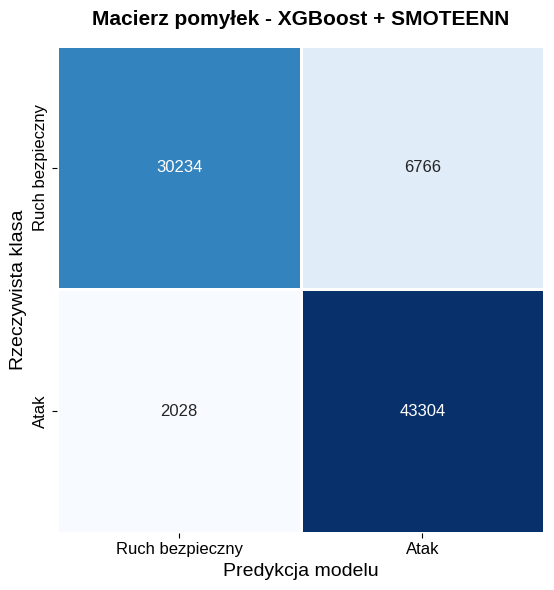

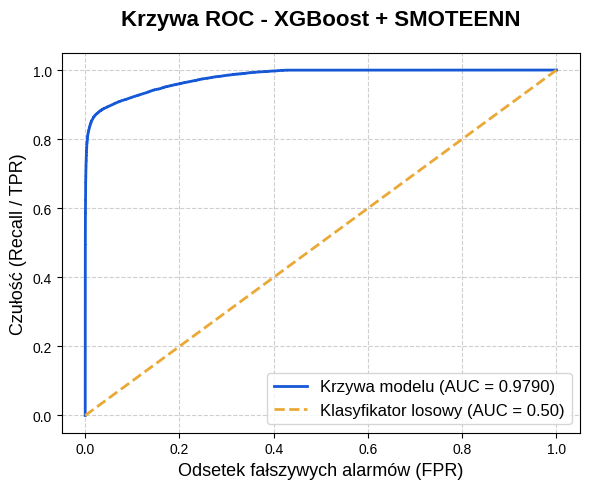

np.float64(0.9790074125789073)

In [11]:
# ============================================================
# 2.5. Implementacja i trenowanie modelu XGBoost
# (SMOTEENN)
# ============================================================
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_xgb, y_train_xgb)

xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.2, max_depth=5, min_child_weight=3, gamma=0, subsample=0.7, random_state=42, eval_metric='aucpr', early_stopping_rounds=20)
xgb_model.fit(X_train_resampled, y_train_resampled, eval_set=[(X_val_xgb, y_val_xgb)], verbose=False)

y_pred_xgb = xgb_model.predict(X_test)
y_scores_xgb_smoteenn = xgb_model.predict_proba(X_test)[:, 1]

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
fpr_xgb = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"FPR: {fpr_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, digits=3))

zapisz_macierz_pomylek(cm_xgb, 'Macierz pomyłek - XGBoost + SMOTEENN', 'confusion_matrix_xgboost_smoteenn.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb, 'raport_xgboost_smoteenn.xlsx')
zapisz_krzywa_roc(y_test, y_scores_xgb_smoteenn, 'Krzywa ROC - XGBoost + SMOTEENN', 'roc_xgboost_smoteenn.png')

Accuracy: 0.8932
FPR: 0.1829
              precision    recall  f1-score   support

           0      0.937     0.817     0.873     37000
           1      0.865     0.955     0.908     45332

    accuracy                          0.893     82332
   macro avg      0.901     0.886     0.890     82332
weighted avg      0.897     0.893     0.892     82332



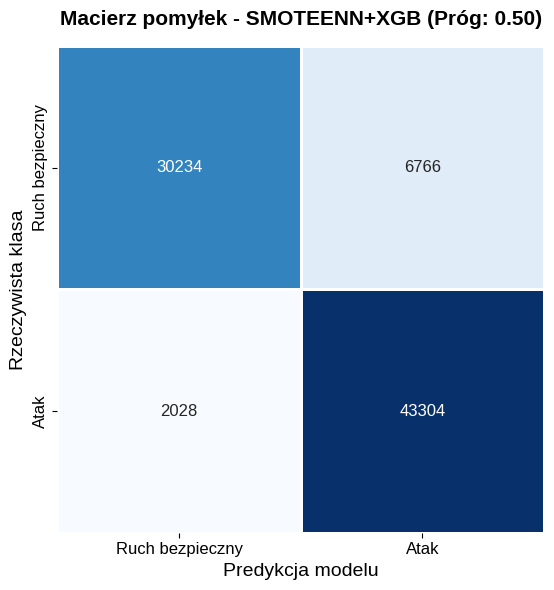

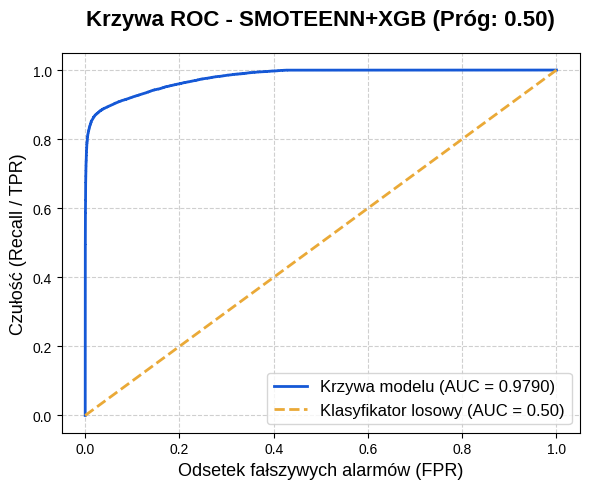

np.float64(0.9790074125789073)

In [12]:
# ============================================================
# 2.6. Implementacja i trenowanie modelu XGBoost
# (SMOTEENN + Dynamic Threshold)
# ============================================================
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_xgb, y_train_xgb)

xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.2, max_depth=5, min_child_weight=3, gamma=0, subsample=0.7, random_state=42, eval_metric='aucpr', early_stopping_rounds=20)
xgb_model.fit(X_train_resampled, y_train_resampled, eval_set=[(X_val_xgb, y_val_xgb)], verbose=False)

prawdopodobienstwa_val = xgb_model.predict_proba(X_val_xgb)[:, 1]
maksymalny_akceptowalny_fpr = 0.05
najlepszy_recall = 0.0
znaleziony_prog = 0.50

for prog in np.arange(0.01, 1.0, 0.01):
    y_pred_temp = (prawdopodobienstwa_val >= prog).astype(int)
    cm_temp = confusion_matrix(y_val_xgb, y_pred_temp)
    tn, fp, fn, tp = cm_temp.ravel()
    obecny_fpr = fp / (fp + tn)
    obecny_recall = recall_score(y_val_xgb, y_pred_temp)
    if obecny_fpr <= maksymalny_akceptowalny_fpr and obecny_recall > najlepszy_recall:
        najlepszy_recall = obecny_recall
        znaleziony_prog = prog

prawdopodobienstwa_test = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb_final = (prawdopodobienstwa_test >= znaleziony_prog).astype(int)

cm_xgb_final = confusion_matrix(y_test, y_pred_xgb_final)
tn, fp, fn, tp = cm_xgb_final.ravel()
fpr_xgb_final = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_final):.4f}")
print(f"FPR: {fpr_xgb_final:.4f}")
print(classification_report(y_test, y_pred_xgb_final, digits=3))

zapisz_macierz_pomylek(cm_xgb_final, f'Macierz pomyłek - SMOTEENN+XGB (Próg: {znaleziony_prog:.2f})', 'confusion_matrix_xgboost_hybrid.png')
zapisz_raport_klasyfikacji(y_test, y_pred_xgb_final, 'raport_xgboost_hybrid.xlsx')
zapisz_krzywa_roc(y_test, prawdopodobienstwa_test, f'Krzywa ROC - SMOTEENN+XGB (Próg: {znaleziony_prog:.2f})', 'roc_xgboost_hybrid.png')

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy: 0.4786
FPR: 0.9359
              precision    recall  f1-score   support

           0      0.222     0.064     0.100     37000
           1      0.517     0.817     0.633     45332

    accuracy                          0.479     82332
   macro avg      0.370     0.441     0.366     82332
weighted avg      0.384     0.479     0.393     82332



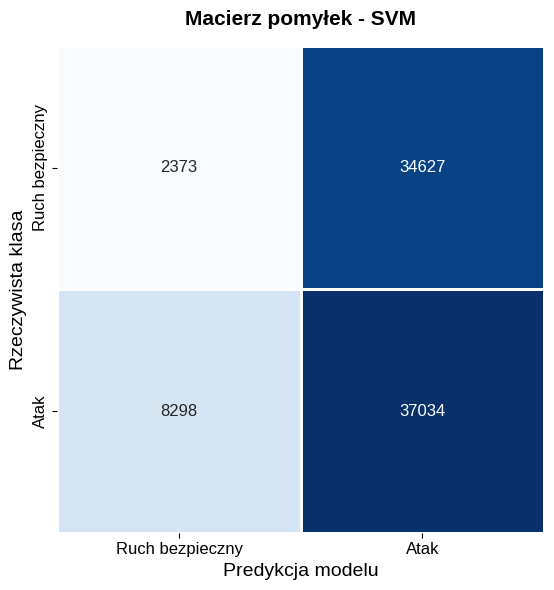

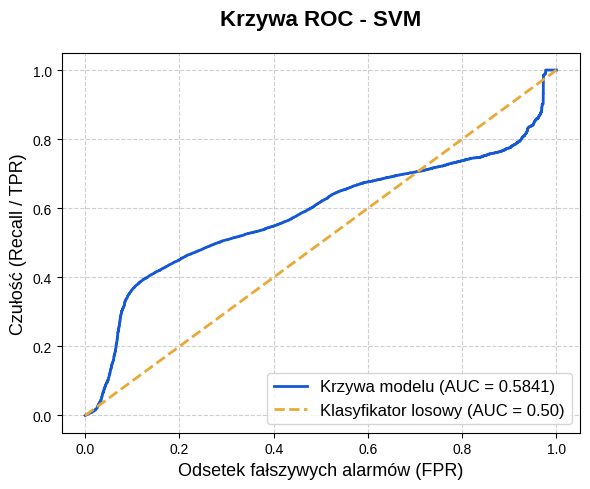

np.float64(0.5840908903918477)

In [13]:
# ============================================================
# 3. Implementacja i trenowanie modelu SVM
# (RBF)
# ============================================================
svm_model = SVC(kernel='rbf', random_state=42, class_weight='balanced', max_iter=5000, cache_size=1000)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)
tn, fp, fn, tp = cm_svm.ravel()
fpr_svm = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"FPR: {fpr_svm:.4f}")
print(classification_report(y_test, y_pred_svm, digits=3))

zapisz_macierz_pomylek(cm_svm, 'Macierz pomyłek - SVM', 'confusion_matrix_svm.png')
zapisz_raport_klasyfikacji(y_test, y_pred_svm, 'raport_svm.xlsx')
y_scores_svm = svm_model.decision_function(X_test)
zapisz_krzywa_roc(y_test, y_scores_svm, 'Krzywa ROC - SVM', 'roc_svm.png')

Accuracy: 0.8301
FPR: 0.2968
              precision    recall  f1-score   support

           0      0.896     0.703     0.788     37000
           1      0.794     0.934     0.858     45332

    accuracy                          0.830     82332
   macro avg      0.845     0.818     0.823     82332
weighted avg      0.840     0.830     0.827     82332



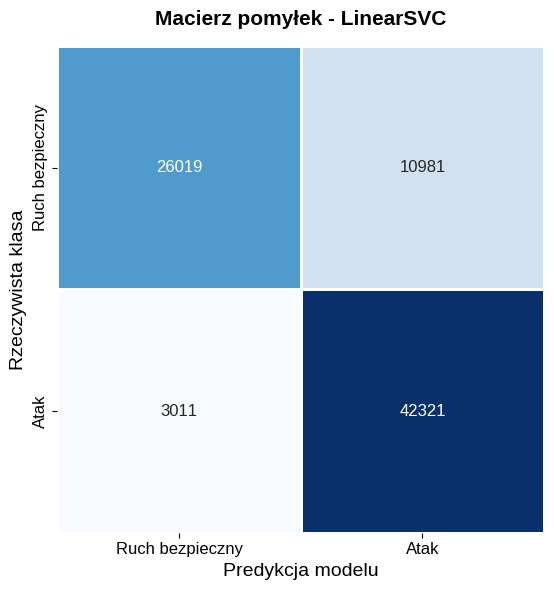

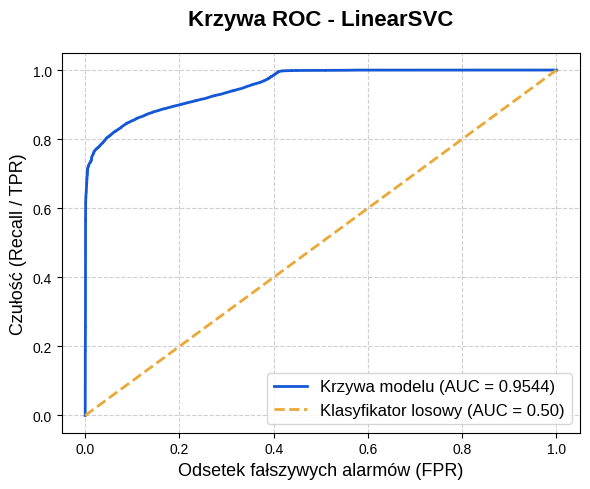

np.float64(0.9543677749266075)

In [14]:
# ============================================================
# 3.1. Implementacja i trenowanie modelu SVM
# (LinearSVC)
# ============================================================
svm_linear_model = LinearSVC(random_state=42, class_weight='balanced', max_iter=5000)
svm_linear_model.fit(X_train, y_train)

y_pred_linear = svm_linear_model.predict(X_test)
y_scores_linear = svm_linear_model.decision_function(X_test)

cm_linear = confusion_matrix(y_test, y_pred_linear)
tn, fp, fn, tp = cm_linear.ravel()
fpr_linear = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_linear):.4f}")
print(f"FPR: {fpr_linear:.4f}")
print(classification_report(y_test, y_pred_linear, digits=3))

zapisz_macierz_pomylek(cm_linear, 'Macierz pomyłek - LinearSVC', 'confusion_matrix_linearsvc.png')
zapisz_raport_klasyfikacji(y_test, y_pred_linear, 'raport_linearsvc.xlsx')
zapisz_krzywa_roc(y_test, y_scores_linear, 'Krzywa ROC - LinearSVC', 'roc_linearsvc.png')

Accuracy: 0.8064
FPR: 0.3530
              precision    recall  f1-score   support

           0      0.893     0.647     0.750     37000
           1      0.765     0.937     0.842     45332

    accuracy                          0.806     82332
   macro avg      0.829     0.792     0.796     82332
weighted avg      0.822     0.806     0.801     82332



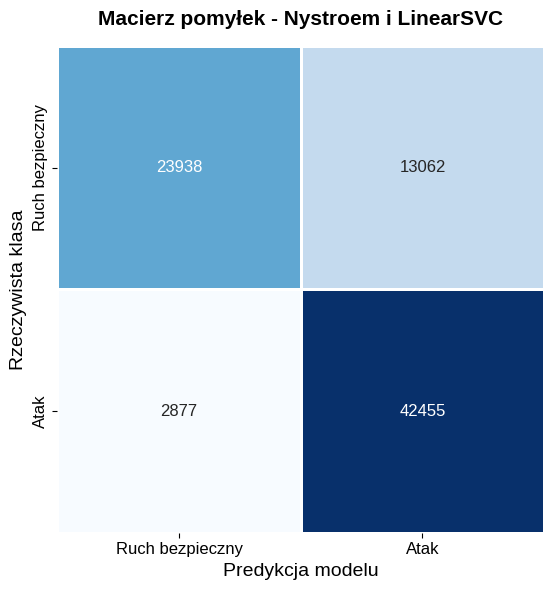

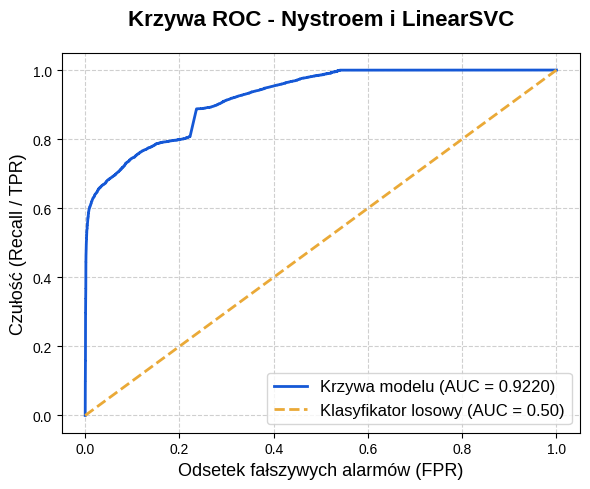

np.float64(0.9219553143653669)

In [15]:
# ============================================================
# 3.2. Implementacja i trenowanie modelu SVM
# (Nystroem + LinearSVC)
# ============================================================
svm_nystroem_model = make_pipeline(Nystroem(gamma=0.2, random_state=42, n_components=300), LinearSVC(random_state=42, class_weight='balanced', max_iter=5000, dual=False))
svm_nystroem_model.fit(X_train, y_train)

y_pred_nystroem = svm_nystroem_model.predict(X_test)
y_scores_nystroem = svm_nystroem_model.decision_function(X_test)

cm_nystroem = confusion_matrix(y_test, y_pred_nystroem)
tn, fp, fn, tp = cm_nystroem.ravel()
fpr_nystroem = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_nystroem):.4f}")
print(f"FPR: {fpr_nystroem:.4f}")
print(classification_report(y_test, y_pred_nystroem, digits=3))

zapisz_macierz_pomylek(cm_nystroem, 'Macierz pomyłek - Nystroem i LinearSVC', 'confusion_matrix_nystroem_linearsvc.png')
zapisz_raport_klasyfikacji(y_test, y_pred_nystroem, 'raport_nystroem_linearsvc.xlsx')
zapisz_krzywa_roc(y_test, y_scores_nystroem, 'Krzywa ROC - Nystroem i LinearSVC', 'roc_nystroem_linearsvc.png')

Accuracy: 0.8378
FPR: 0.2744
              precision    recall  f1-score   support

           0      0.893     0.726     0.801     37000
           1      0.806     0.929     0.863     45332

    accuracy                          0.838     82332
   macro avg      0.850     0.827     0.832     82332
weighted avg      0.845     0.838     0.835     82332



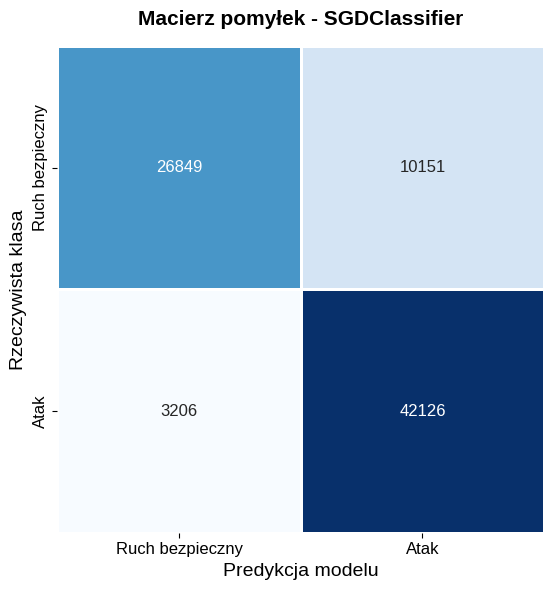

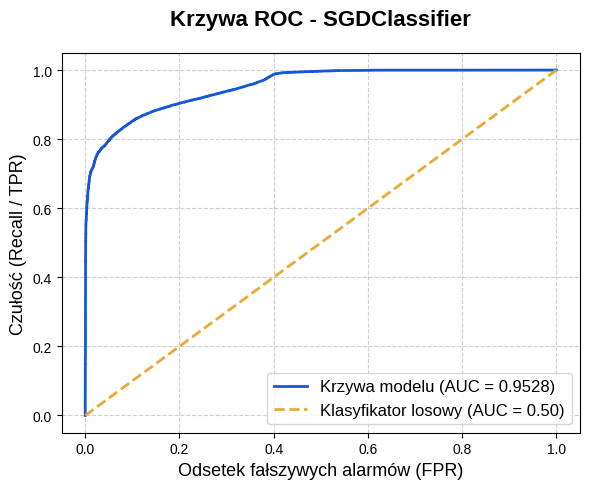

np.float64(0.9528445725351223)

In [16]:
# ============================================================
# 3.3. Implementacja i trenowanie modelu SVM
# (SGDClassifier)
# ============================================================
svm_sgd_model = SGDClassifier(loss='hinge', random_state=42, class_weight='balanced', max_iter=5000)
svm_sgd_model.fit(X_train, y_train)

y_pred_svm_sgd = svm_sgd_model.predict(X_test)
y_scores_svm_sgd = svm_sgd_model.decision_function(X_test)

cm_svm_sgd = confusion_matrix(y_test, y_pred_svm_sgd)
tn, fp, fn, tp = cm_svm_sgd.ravel()
fpr_svm_sgd = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_sgd):.4f}")
print(f"FPR: {fpr_svm_sgd:.4f}")
print(classification_report(y_test, y_pred_svm_sgd, digits=3))

zapisz_macierz_pomylek(cm_svm_sgd, 'Macierz pomyłek - SGDClassifier', 'confusion_matrix_sgdclassifier.png')
zapisz_raport_klasyfikacji(y_test, y_pred_svm_sgd, 'raport_sgdclassifier.xlsx')
zapisz_krzywa_roc(y_test, y_scores_svm_sgd, 'Krzywa ROC - SGDClassifier', 'roc_sgdclassifier.png')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.8605
FPR: 0.2967
              precision    recall  f1-score   support

           0      0.981     0.703     0.819     37000
           1      0.803     0.989     0.886     45332

    accuracy                          0.861     82332
   macro avg      0.892     0.846     0.853     82332
weighted avg      0.883     0.861     0.856     82332



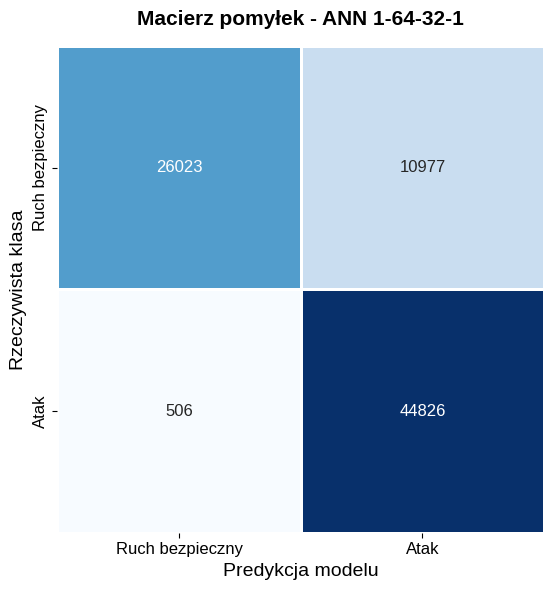

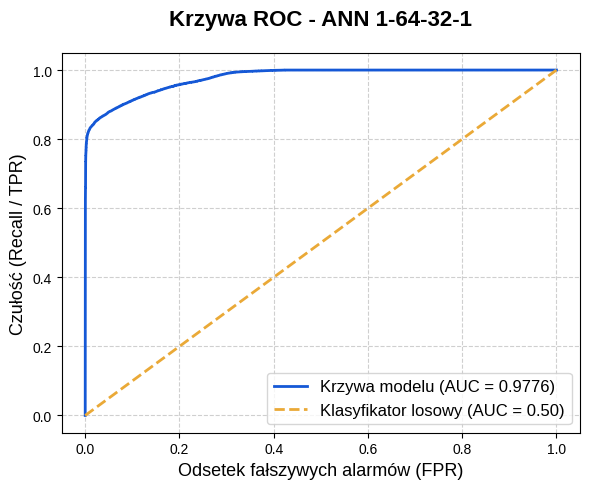

In [17]:
# ============================================================
# 4. Implementacja i trenowanie modelu ANN
# (1-64-32-1)
# ============================================================
ann_model = Sequential()
ann_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
ann_model.add(Dropout(0.3))
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dropout(0.2))
ann_model.add(Dense(1, activation='sigmoid'))
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = ann_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=0)

y_pred_proba_ann = ann_model.predict(X_test, verbose=0)
y_pred_ann = (y_pred_proba_ann > 0.5).astype(int)
y_scores_ann = y_pred_proba_ann.ravel()

cm_ann = confusion_matrix(y_test, y_pred_ann)
tn, fp, fn, tp = cm_ann.ravel()
fpr_ann = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_ann):.4f}")
print(f"FPR: {fpr_ann:.4f}")
print(classification_report(y_test, y_pred_ann, digits=3))

zapisz_macierz_pomylek(cm_ann, 'Macierz pomyłek - ANN 1-64-32-1', 'confusion_matrix_ann.png')
zapisz_raport_klasyfikacji(y_test, y_pred_ann, 'raport_ann.xlsx')
zapisz_krzywa_roc(y_test, y_scores_ann, 'Krzywa ROC - ANN 1-64-32-1', 'roc_ann.png')

kat_lc = os.path.join(folder_path, "learning_curve")
os.makedirs(kat_lc, exist_ok=True)

plt.figure(figsize=(6, 5))
plt.plot(history.history['loss'], label='Błąd na Treningu', color='#1558d6', linewidth=2)
plt.plot(history.history['val_loss'], label='Błąd na Walidacji', color='#eaa937', linewidth=2)
plt.title('Historia uczenia - ANN 1-64-32-1', fontsize=16, pad=20, weight='bold')
plt.xlabel('Epoka', fontsize=13)
plt.ylabel('Wartość Błędu', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(kat_lc, 'learning_curve_ann.png'), dpi=300, bbox_inches='tight')
plt.close()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.8198
FPR: 0.3943
              precision    recall  f1-score   support

           0      0.989     0.606     0.751     37000
           1      0.756     0.995     0.859     45332

    accuracy                          0.820     82332
   macro avg      0.872     0.800     0.805     82332
weighted avg      0.860     0.820     0.810     82332



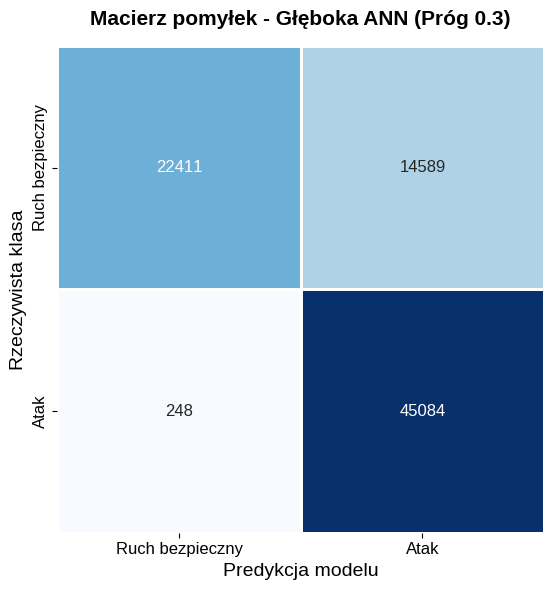

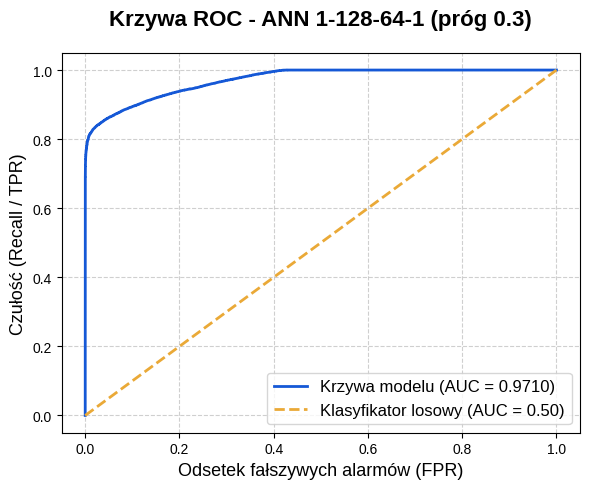

In [18]:
# ============================================================
# 4.1. Implementacja i trenowanie modelu ANN
# (1-128-64-32-1)
# ============================================================
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weights_dict = {0: class_weights[0], 1: class_weights[1]}

ann_opt_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), Dropout(0.3),
    Dense(64, activation='relu'), Dropout(0.3),
    Dense(32, activation='relu'), Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_opt_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop_opt = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

history_opt = ann_opt_model.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.2,
                                class_weight=weights_dict, callbacks=[early_stop_opt], verbose=0)

y_pred_proba_ann_opt = ann_opt_model.predict(X_test, verbose=0)
ann_threshold = 0.30
y_pred_ann_opt = (y_pred_proba_ann_opt > ann_threshold).astype(int)
y_scores_ann_opt = y_pred_proba_ann_opt.ravel()

cm_ann_opt = confusion_matrix(y_test, y_pred_ann_opt)
tn, fp, fn, tp = cm_ann_opt.ravel()
fpr_ann_opt = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_ann_opt):.4f}")
print(f"FPR: {fpr_ann_opt:.4f}")
print(classification_report(y_test, y_pred_ann_opt, digits=3))

zapisz_macierz_pomylek(cm_ann_opt, f'Macierz pomyłek - Głęboka ANN (Próg {ann_threshold})', 'confusion_matrix_deep_ann.png')
zapisz_raport_klasyfikacji(y_test, y_pred_ann_opt, 'raport_deep_ann.xlsx')
zapisz_krzywa_roc(y_test, y_scores_ann_opt, f'Krzywa ROC - ANN 1-128-64-1 (próg {ann_threshold})', 'roc_deep_ann.png')

plt.figure(figsize=(6, 5))
plt.plot(history_opt.history['loss'], label='Błąd na Treningu', color='#1558d6', linewidth=2)
plt.plot(history_opt.history['val_loss'], label='Błąd na Walidacji', color='#eaa937', linewidth=2)
plt.title(f'Historia uczenia - Głęboka ANN (Próg {ann_threshold})', fontsize=16, pad=20, weight='bold')
plt.xlabel('Epoka', fontsize=13)
plt.ylabel('Wartość Błędu', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(kat_lc, 'learning_curve_deep_ann.png'), dpi=300, bbox_inches='tight')
plt.close()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.8492
FPR: 0.2797
              precision    recall  f1-score   support

           0      0.928     0.720     0.811     37000
           1      0.807     0.954     0.875     45332

    accuracy                          0.849     82332
   macro avg      0.868     0.837     0.843     82332
weighted avg      0.861     0.849     0.846     82332



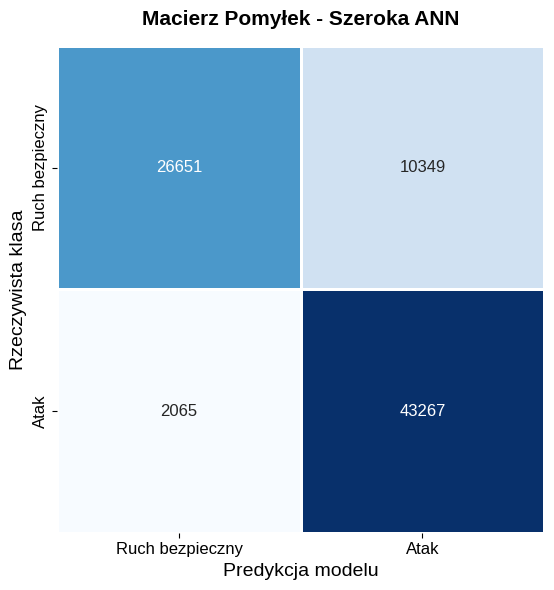

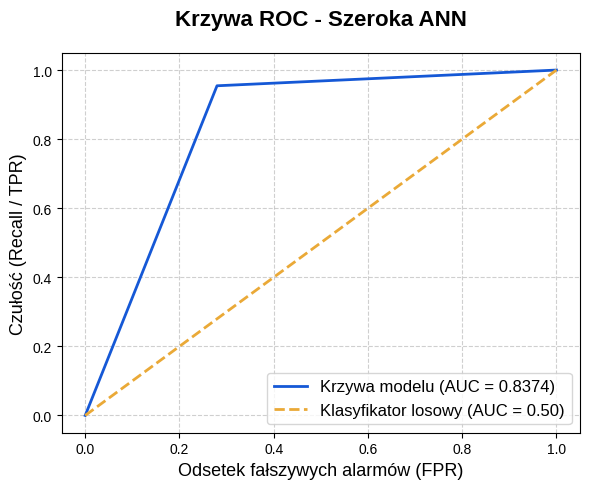

In [19]:
# ============================================================
# 4.2. Implementacja i trenowanie modelu ANN
# (Szeroka sieć, 256-128-64-1, wagi klas)
# ============================================================
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)
wagi = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_split), y=y_train_split)
class_weight_dict = dict(zip(np.unique(y_train_split), wagi))

ann_wide_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_split.shape[1],)), BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu'), BatchNormalization(), Dropout(0.2),
    Dense(64, activation='relu'), BatchNormalization(), Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_wide_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

history_wide = ann_wide_model.fit(X_train_split, y_train_split, epochs=100, batch_size=64, class_weight=class_weight_dict,
                                  validation_data=(X_val, y_val), callbacks=[early_stop, reduce_lr], verbose=0)

y_pred_proba_wide = ann_wide_model.predict(X_test, verbose=0)
y_pred_ann_wide = (y_pred_proba_wide > 0.5).astype(int).ravel()
y_scores_ann_wide = y_pred_ann_wide.ravel()

cm_wide_ann = confusion_matrix(y_test, y_pred_ann_wide)
tn, fp, fn, tp = cm_wide_ann.ravel()
fpr_wide_ann = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred_ann_wide):.4f}")
print(f"FPR: {fpr_wide_ann:.4f}")
print(classification_report(y_test, y_pred_ann_wide, digits=3))

zapisz_macierz_pomylek(cm_wide_ann, 'Macierz Pomyłek - Szeroka ANN', 'confusion_matrix_wide_ann.png')
zapisz_raport_klasyfikacji(y_test, y_pred_ann_wide, 'raport_wide_ann.xlsx')
zapisz_krzywa_roc(y_test, y_scores_ann_wide, 'Krzywa ROC - Szeroka ANN', 'roc_wide_ann.png')

plt.figure(figsize=(6, 5))
plt.plot(history_wide.history['loss'], label='Błąd na Treningu', color='#1558d6', linewidth=2)
plt.plot(history_wide.history['val_loss'], label='Błąd na Walidacji', color='#eaa937', linewidth=2)
plt.title('Historia uczenia - Szeroka ANN z Wagami', fontsize=16, pad=20, weight='bold')
plt.xlabel('Epoka', fontsize=13)
plt.ylabel('Wartość Błędu', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(kat_lc, 'learning_curve_wide_ann.png'), dpi=300, bbox_inches='tight')
plt.close()